In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
df=pd.read_csv(r"C:\Users\kumar\Downloads\datalab_export_2026-09-24 18_16_16.csv")
df.head()

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,1,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850,United Kingdom
1,2,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850,United Kingdom
2,3,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850,United Kingdom
3,4,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850,United Kingdom
4,5,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850,United Kingdom


PERFORRMING EDA

In [9]:
df.shape
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   index        100 non-null    int64  
 1   InvoiceNo    100 non-null    int64  
 2   StockCode    100 non-null    object 
 3   Description  100 non-null    object 
 4   Quantity     100 non-null    int64  
 5   InvoiceDate  100 non-null    object 
 6   UnitPrice    100 non-null    float64
 7   CustomerID   100 non-null    int64  
 8   Country      100 non-null    object 
dtypes: float64(1), int64(4), object(4)
memory usage: 7.2+ KB


Index(['index', 'InvoiceNo', 'StockCode', 'Description', 'Quantity',
       'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [10]:
df.describe()

,index,InvoiceNo,Quantity,UnitPrice,CustomerID
count,100.000000,100.000000,100.000000,100.000000,100.000000
mean,50.500000,536371.870000,13.100000,3.276400,15417.710000
std,29.011492,4.041839,16.887925,2.611142,2319.990749
min,1.000000,536365.000000,2.000000,0.420000,12583.000000
25%,25.750000,536368.750000,6.000000,1.680000,13047.000000
50%,50.500000,536373.000000,6.000000,2.650000,14688.000000
75%,75.250000,536375.000000,13.500000,4.250000,17850.000000
max,100.000000,536378.000000,120.000000,18.000000,17850.000000


In [11]:
df.isnull()

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
95,False,False,False,False,False,False,False,False,False
96,False,False,False,False,False,False,False,False,False
97,False,False,False,False,False,False,False,False,False
98,False,False,False,False,False,False,False,False,False


In [12]:
df.isnull().sum()

index          0
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [14]:
df.loc[1,"UnitPrice"]=0

In [15]:
df.head

<bound method NDFrame.head of     index  InvoiceNo StockCode                          Description  Quantity  \
0       1     536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1       2     536365     71053                  WHITE METAL LANTERN         6   
2       3     536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3       4     536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4       5     536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
..    ...        ...       ...                                  ...       ...   
95     96     536378     22352     LUNCH BOX WITH CUTLERY RETROSPOT         6   
96     97     536378     21212      PACK OF 72 RETROSPOT CAKE CASES       120   
97     98     536378     21975       PACK OF 60 DINOSAUR CAKE CASES        24   
98     99     536378     21977   PACK OF 60 PINK PAISLEY CAKE CASES        24   
99    100     536378     84991          60 TEATIME FAIRY CAKE CASES        24  

In [16]:
df.head()

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,1,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850,United Kingdom
1,2,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,0.00,17850,United Kingdom
2,3,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850,United Kingdom
3,4,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850,United Kingdom
4,5,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850,United Kingdom


In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df=df.drop_duplicates()

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df["InvoiceDate"].dtype

dtype('O')

In [24]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

C:\Users\kumar\AppData\Local\Temp\ipykernel_7288\3012402086.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])


In [26]:
df["InvoiceDate"]=pd.to_datetime(df["InvoiceDate"], format="%m/%D/%Y %H/%T")

In [27]:
df["Year"] = df["InvoiceDate"].dt.year

In [54]:
df["Month"] = df["InvoiceDate"].dt.month
df["Day"] = df["InvoiceDate"].dt.day

In [30]:
df["sales"df["Quantity"]*]=df["UnitPrice"]

In [31]:
df.head()

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Year,Month,Day,sales
0,1,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,2010,12,1,15.30
1,2,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,0.00,17850,United Kingdom,2010,12,1,0.00
2,3,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,2010,12,1,22.00
3,4,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010,12,1,20.34
4,5,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010,12,1,20.34


In [32]:
total_sales = df["sales"].sum()

print("Total Sales:", total_sales)

Total Sales: 3102.5899999999997


In [33]:
total_quantity = df["Quantity"].sum()

print("Total Quantity Sold:", total_quantity)

Total Quantity Sold: 1310


In [34]:
df.loc[1,"UnitPrice"]=5

In [38]:
df["sales"]=df["Quantity"]*df["UnitPrice"]

In [59]:
df.head()
df.tail()

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Year,Month,Day,sales
95,96,536378,22352,LUNCH BOX WITH CUTLERY RETROSPOT,6,2010-12-01 09:37:00,2.55,14688,United Kingdom,2010,12,1,15.3
96,97,536378,21212,PACK OF 72 RETROSPOT CAKE CASES,120,2010-12-01 09:37:00,0.42,14688,United Kingdom,2010,12,1,50.4
97,98,536378,21975,PACK OF 60 DINOSAUR CAKE CASES,24,2010-12-01 09:37:00,0.55,14688,United Kingdom,2010,12,1,13.2
98,99,536378,21977,PACK OF 60 PINK PAISLEY CAKE CASES,24,2010-12-01 09:37:00,0.55,14688,United Kingdom,2010,12,1,13.2
99,100,536378,84991,60 TEATIME FAIRY CAKE CASES,24,2010-12-01 09:37:00,0.55,14688,United Kingdom,2010,12,1,13.2


In [40]:
total_sales = df["sales"].sum()

print("Total Sales:", total_sales)

Total Sales: 3132.5899999999997


In [41]:
total_quantity = df["Quantity"].sum()

print("Total Quantity Sold:", total_quantity)

Total Quantity Sold: 1310


In [43]:
total_customers = df["CustomerID"].nunique()

print("Total Customers:", total_customers)

total_orders=df["Quantity"].sum()

Total Customers: 7


CALCULATING AVERAGE ORDER VALUE

In [45]:
avg=total_sales/total_orders
print("average order: ",avg)

average order:  2.3912900763358778


In [48]:
monthly_sales = df.groupby("Month")["sales"].sum()

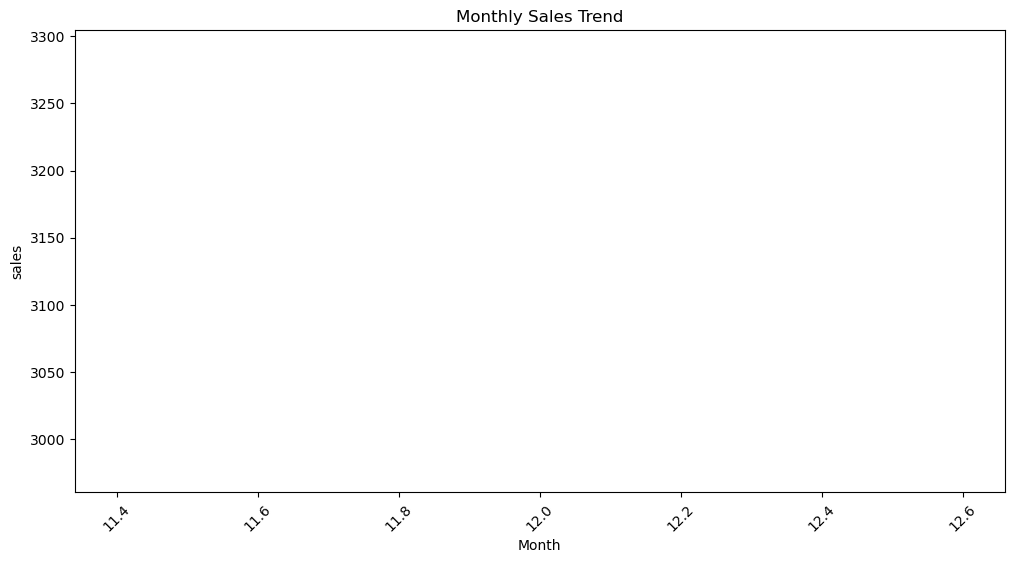

In [50]:
plt.figure(figsize=(12,6))

plt.plot(monthly_sales.index, monthly_sales.values)

plt.xlabel("Month")
plt.ylabel("sales")
plt.title("Monthly Sales Trend")

plt.xticks(rotation=45)

plt.show()

In [55]:
monthly_sales = df.groupby("Month")["sales"].sum()

print(monthly_sales)

Month
12    3132.59
Name: sales, dtype: float64


In [56]:
perday_sales=df.groupby("Day")["sales"].sum()

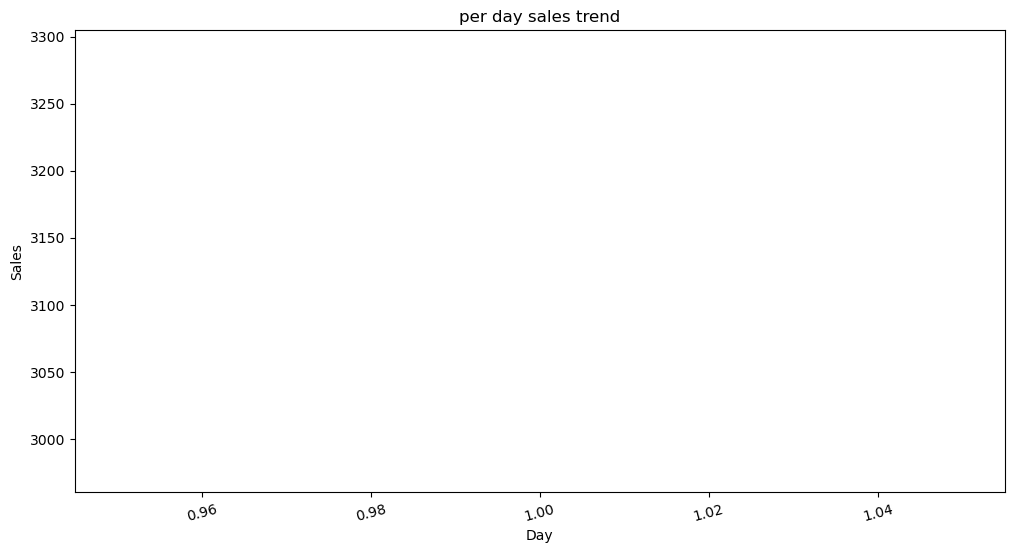

In [58]:
plt.figure(figsize=(12,6))

plt.plot(perday_sales.index, perday_sales.values)

plt.xlabel("Day")
plt.ylabel("Sales")
plt.title("per day sales trend")

plt.xticks(rotation=15)

plt.show()